# Task2: Preprocessing & Feature Engineering 

Import Libraries:

In [43]:
# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
import copy

Import cleaned dataset:

In [44]:
# import cleaned data of cleveland
X = pd.read_csv("../data/02_cleaned/cleaned_dataframe.csv")
y = pd.read_csv("../data/02_cleaned/target_dataframe.csv")

In [45]:
# Convert target to binary
y = (y['target'] > 0).astype(int)

In [46]:
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
for i in cat_features:
    X[i] = X[i].astype('category')

X.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       303 non-null    int64   
 1   sex       303 non-null    category
 2   cp        303 non-null    category
 3   trestbps  303 non-null    int64   
 4   chol      303 non-null    int64   
 5   fbs       303 non-null    category
 6   restecg   303 non-null    category
 7   thalach   303 non-null    int64   
 8   exang     303 non-null    category
 9   oldpeak   303 non-null    float64 
 10  slope     303 non-null    category
 11  ca        303 non-null    int64   
 12  thal      303 non-null    category
dtypes: category(7), float64(1), int64(5)
memory usage: 16.7 KB


## 1. Encode categorical features

Although several variables were stored as numeric types, such as **(`sex`, `cp`[chest pain], `fbs`[fasting blood sugar], `restcg`, `examg`, `slope`, `thal`)**. These variable were therefore treated as categorical and encoded using-hot enconding to avoid introducing artificial ordinal relationship.

We used [get.dummies()](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html) to convert categorical variable into dummy/indicator varianle

In [47]:
def encode_and_bind(original_dataframe, feature_to_encode):
    dummies = pd.get_dummies(original_dataframe[[feature_to_encode]])
    res = pd.concat([original_dataframe, dummies], axis=1)
    res = res.drop([feature_to_encode], axis=1)
    return(res)

In [48]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       303 non-null    int64   
 1   sex       303 non-null    category
 2   cp        303 non-null    category
 3   trestbps  303 non-null    int64   
 4   chol      303 non-null    int64   
 5   fbs       303 non-null    category
 6   restecg   303 non-null    category
 7   thalach   303 non-null    int64   
 8   exang     303 non-null    category
 9   oldpeak   303 non-null    float64 
 10  slope     303 non-null    category
 11  ca        303 non-null    int64   
 12  thal      303 non-null    category
dtypes: category(7), float64(1), int64(5)
memory usage: 16.7 KB


In [49]:
# selects columns in the dataset that are of type category
cat_features = list(X.select_dtypes(include=['category']))

X_enc = copy.deepcopy(X)    # create a deep copy of X to ensure the original dataset be modified
for i in cat_features:
    X_enc = encode_and_bind(X_enc, i)

# Drop redundancy dummy variables to avoid multicollinearity  
X_enc.rename(columns = {
    'sex_1': 'is_male',
    'fbs_1': 'is_fbs',
    'exang_1': 'is_exang'
}, inplace=True)

X_enc.drop(columns=['sex_0', 'fbs_0', 'exang_0'], inplace=True)

X_enc.head()

,age,trestbps,chol,thalach,oldpeak,ca,is_male,cp_1,cp_2,cp_3,...,restecg_0,restecg_1,restecg_2,is_exang,slope_1,slope_2,slope_3,thal_3,thal_6,thal_7
0,63,145,233,150,2.3,0,True,True,False,False,...,False,False,True,False,False,False,True,False,True,False
1,67,160,286,108,1.5,3,True,False,False,False,...,False,False,True,True,False,True,False,True,False,False
2,67,120,229,129,2.6,2,True,False,False,False,...,False,False,True,True,False,True,False,False,False,True
3,37,130,250,187,3.5,0,True,False,False,True,...,True,False,False,False,False,False,True,True,False,False
4,41,130,204,172,1.4,0,False,False,True,False,...,False,False,True,False,True,False,False,True,False,False


After encoding and drop redundant dummy variables the dataset contained 22 features, including both numerical variables and one-hot encoded categorical variable.

## 2. Feature Scaling and Standardization

Standardization was applied using the `StandardScaler` from `sklearn`. This method subtract the mean and divides by standard deviation for each feature, resulting in variable with zero mean and unit variance

In [51]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_enc)

print("Means:", scaler.mean_)
print("Variances:", scaler.var_)

Means: [5.44389439e+01 1.31689769e+02 2.46693069e+02 1.49607261e+02
 1.03960396e+00 6.63366337e-01 6.79867987e-01 7.59075908e-02
 1.65016502e-01 2.83828383e-01 4.75247525e-01 1.48514851e-01
 4.98349835e-01 1.32013201e-02 4.88448845e-01 3.26732673e-01
 4.68646865e-01 4.62046205e-01 6.93069307e-02 5.54455446e-01
 5.94059406e-02 3.86138614e-01]
Variances: [8.14277903e+01 3.08728839e+02 2.67200150e+03 5.21538825e+02
 1.34364605e+00 8.70176127e-01 2.17647507e-01 7.01456284e-02
 1.37786056e-01 2.03269832e-01 2.49387315e-01 1.26458190e-01
 2.49997277e-01 1.30270453e-02 2.49866571e-01 2.19978433e-01
 2.49016981e-01 2.48559509e-01 6.45034801e-02 2.47034604e-01
 5.58768748e-02 2.37035585e-01]


The computer **means and variances** show substantial differences in the scale of the variables, with some features exhibiting significantly larger variability than others. This imbalance would bias distance-based methods such as PCA. Therefore, standardization was applied to normalize all features to a common scale, ensuring that no single variable dominates the analysis.

## Step A: Principal Component Analysis

In [74]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print(explained)
print(cumulative)

[1.97450293e-01 9.69915115e-02 7.72300821e-02 7.28919184e-02
 6.51021508e-02 6.12967369e-02 5.54526809e-02 5.31196104e-02
 4.63277680e-02 4.31557884e-02 4.06585638e-02 3.62369971e-02
 3.48292693e-02 3.17996454e-02 2.82237463e-02 2.37223542e-02
 1.87227048e-02 1.67881786e-02 3.66525084e-17 2.98799985e-17
 0.00000000e+00 0.00000000e+00]
[0.19745029 0.2944418  0.37167189 0.44456381 0.50966596 0.57096269
 0.62641537 0.67953498 0.72586275 0.76901854 0.8096771  0.8459141
 0.88074337 0.91254302 0.94076676 0.96448912 0.98321182 1.
 1.         1.         1.         1.        ]


from the output: 
PC1 &asymp; 19.3%, captures the most variation
PC2 &asymp; 10.0% and PC3 &asymp; 9.2%
The variance is spread across many components

### A.1 Plot Explained Variance per Component and cumulative Variance

#### Explained Variance per Component:

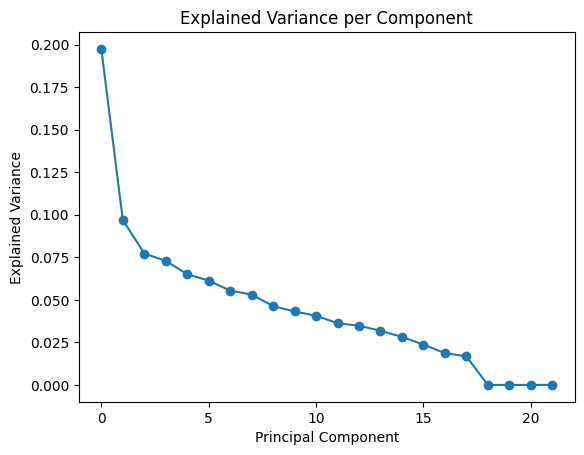

In [53]:
plt.plot(explained, marker='o')
plt.title("Explained Variance per Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.show()

We see that Sharp drop from PC1 to PC2, it means gradual decline, no very strong **elbow**.
The dataset does not have a very low intrinsic dimensionality

#### Cumulative Variance

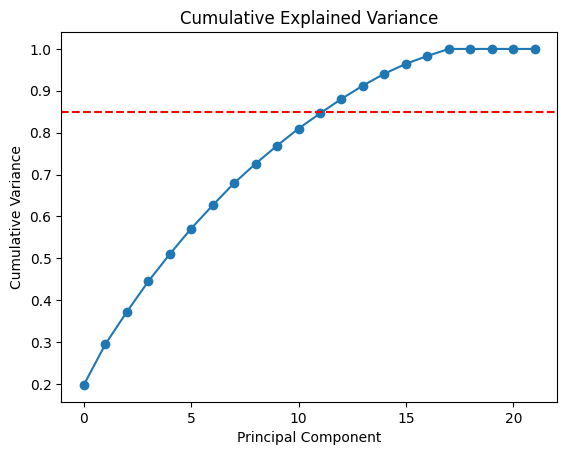

In [54]:
plt.plot(cumulative, marker='o')
plt.axhline(y=0.85, color='r', linestyle='--') # threshold at 85%
plt.title("Cumulative Explained Variance")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance")
plt.show()

The cumulative explained variance plot shows that approximately 12 principal components are required to retain at least 85% of the total variance in the dataset. This show that the dataset does not have a strong low-dimensional structure and that several components are needed to adequately capture the variability in the data
The absence of a clear elbow point further suggest that the data not exhibit strong redundancy and multiple dimensions are required to represent its structure

### A.2 Select components ($\geq$ 85\%)

In [55]:
n_components = np.argmax(cumulative >= 0.85) + 1
print("Number of components (≥ 85% variance):", n_components)

Number of components (≥ 85% variance): 13


### A.3 Visualize first two principal components

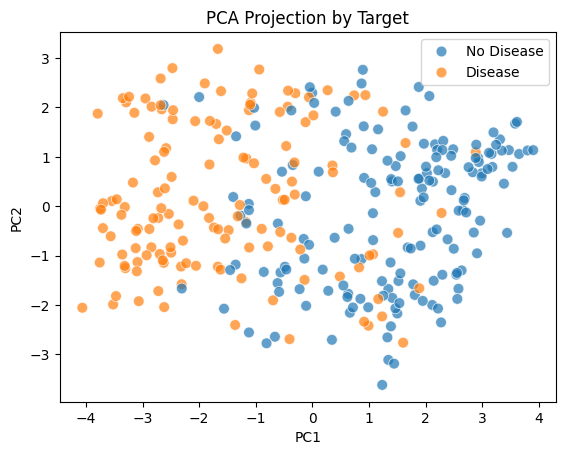

In [56]:
plt.figure()

# Plot each class separately
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue = y.map({0: "No Disease", 1: "Disease"}),
    s = 60,
    alpha = 0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection by Target")
plt.legend()
plt.show()

**3D Plot - First 3 PCA components -  Xnew contains 3 features**

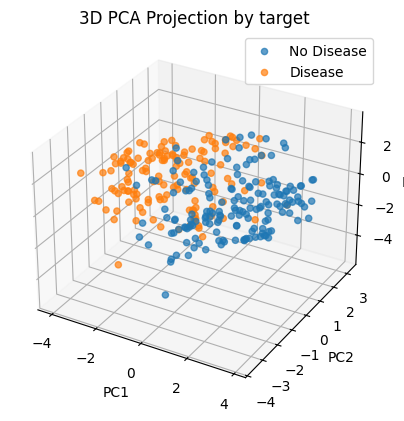

In [57]:
fig = plt.figure()
ax  = fig.add_subplot(111, projection='3d')

# Plot each class separately
ax.scatter(X_pca[y ==0, 0], X_pca[y == 0, 1], X_pca[y == 0 ,2], alpha=0.7 , label = "No Disease")
ax.scatter(X_pca[y ==1, 0], X_pca[y == 1, 1], X_pca[y == 1 ,2], alpha=0.7 , label = "Disease")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Projection by target")

ax.legend()
plt.show()


- The PCA projection was colored according to the target variable, where `0` represents absence of heart disease and `1` represents presence of disease.\
- The overlap between classes indicates that the first two principal components do not clearly separate the two groups.

## Step B: Feature selection supervised

### B.1 Train -test split

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### Encode target 
The `Target` is the diagnosis of heart disease, the original variable name is `num`.

In [59]:
# Define transform fro the target labels
label_encoder = LabelEncoder() # Fit and transform the training data
y_train_enc = label_encoder.fit_transform(y_train) # Transform the testing data
y_test_enc = label_encoder.transform(y_test)

#### Rescale features
The scaled model must be fitted only with the training subset, and then applied in both subsets (train and test).

In [60]:
scaler_split = MinMaxScaler()
X_train_scaled = scaler_split.fit_transform(X_train)
X_test_scaled = scaler_split.transform(X_test)

### B.2 Feature Selection Methods

#### K-best (Univariate)
For **Univariate method** we will use **ANOVA F-test**  selected the most relevant features based on their statistical relationship with the target variable.

In [61]:
fs1 = SelectKBest(score_func=f_classif, k='all')

fs1 = fs1.fit(X_train_scaled, y_train_enc)
X_train_kbest = fs1.transform(X_train_scaled)
X_test_kbest = fs1.transform(X_test_scaled)

p-Value:

In [62]:
p_val = fs1.pvalues_
print(p_val)

[1.03344329e-03 3.43554479e-02 2.31549992e-01 3.35839073e-11
 2.54915651e-10 2.40011802e-13 1.00043502e-06 1.94409854e-01
 2.29484840e-05 2.07674137e-05 8.37568814e-16 4.77371175e-01
 1.49951479e-02 3.58386136e-01 1.06798785e-02 8.93112525e-12
 3.33128707e-09 4.72909362e-08 3.90548914e-01 8.12764721e-20
 2.27788671e-01 6.41855909e-18]


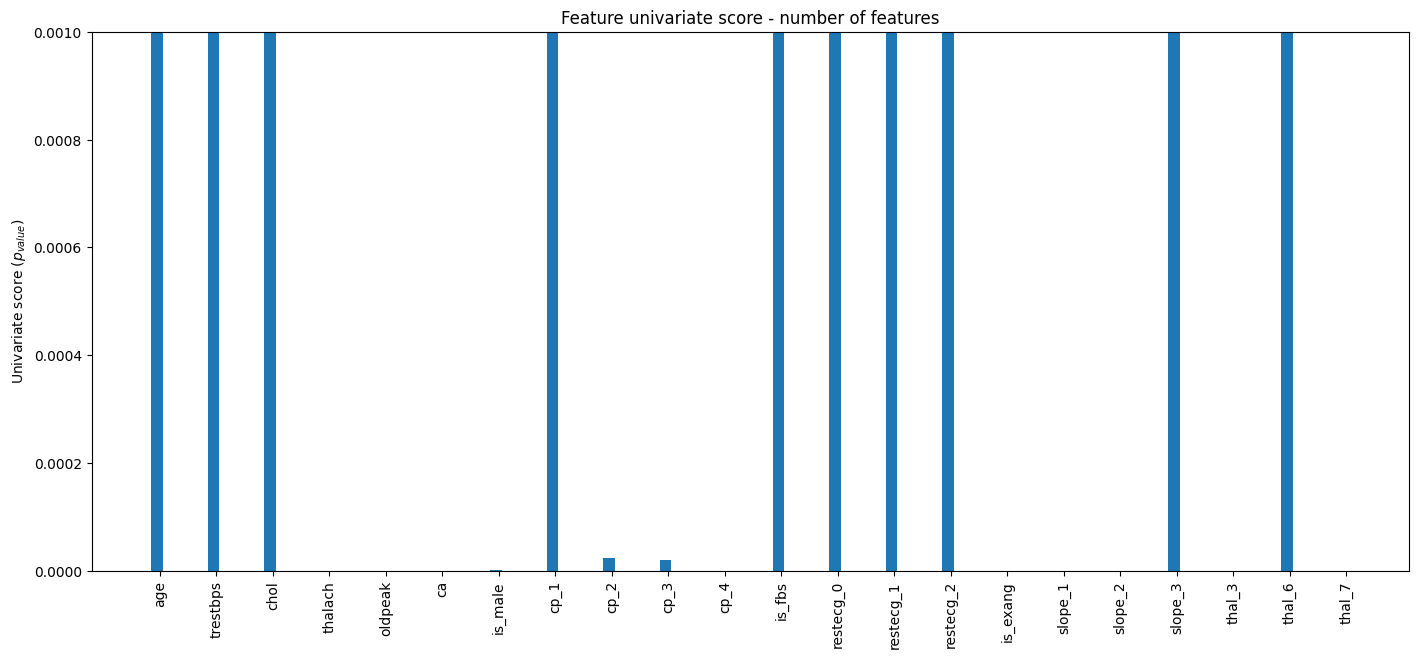

In [63]:
X_indices = np.arange(X_train.shape[-1])
# Create the plot
plt.figure(figsize=(17,7))
plt.figure(1)
plt.clf()
plt.bar(X_indices - 0.05, p_val, width=0.2)
plt.title("Feature univariate score - number of features")
plt.xticks(range(0,len(X_train.columns)),X_train.columns, rotation=90)
plt.ylabel("Univariate score ($p_{value}$)")
plt.ylim([0,0.001])
plt.show()

In [64]:
cols = np.where(p_val<0.001)[0]
temp = X_train_scaled[:,cols]
print("Number of features:", len(cols))

Number of features: 12


In [65]:
X_train.columns[cols]

Index(['thalach', 'oldpeak', 'ca', 'is_male', 'cp_2', 'cp_3', 'cp_4',
       'is_exang', 'slope_1', 'slope_2', 'thal_3', 'thal_7'],
      dtype='str')

F-Score:

In [66]:
f_scores = fs1.scores_ # ANOVA test (f_classif)

n = X_train_scaled.shape[0] # Total number of samples
k = len(np.unique(y_train_enc)) # Number of groups/classes

df_between = k-1 # Degrees of freedom between
df_within = n-k # Degrees of freedom within
eta_squared = (f_scores*df_between) / ((f_scores*df_between) + df_within)

eta_squared

array([0.04395885, 0.01851908, 0.00595842, 0.16766989, 0.1537825 ,
       0.20067247, 0.09507501, 0.00700613, 0.07211975, 0.07285601,
       0.23697591, 0.00210576, 0.02440295, 0.00351588, 0.02684713,
       0.17663541, 0.13588531, 0.11708502, 0.00307347, 0.29292053,
       0.00605513, 0.26697733])

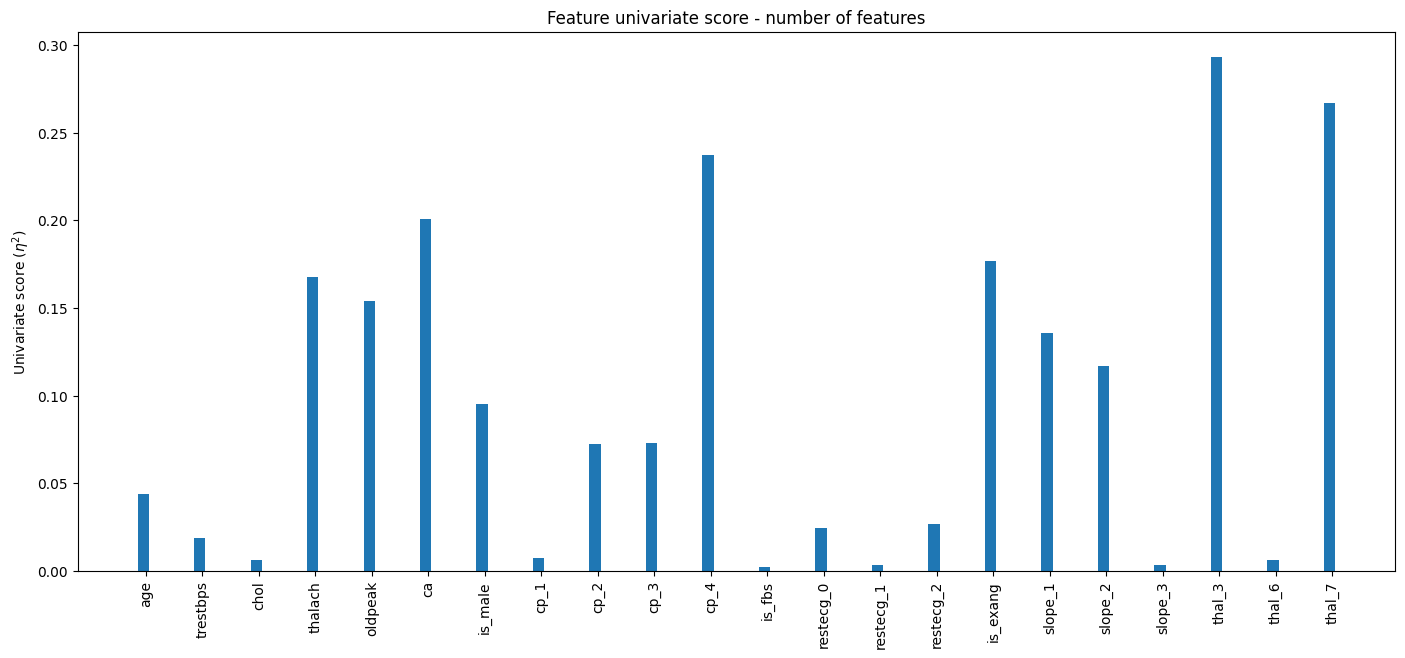

In [67]:
X_indices = np.arange(X_train.shape[-1])
# Create the plot
plt.figure(figsize=(17,7))
plt.figure(1)
plt.clf()
plt.bar(X_indices - 0.05, eta_squared, width=0.2)
plt.title("Feature univariate score - number of features")
plt.xticks(range(0,len(X_train.columns)),X_train.columns, rotation=90)
plt.ylabel("Univariate score ($\eta^2$)")
plt.show()

- $0.01$: The feature explains 1% of variance (little effect)
- $0.06$: The feature explains 6% of variance (medium effect)
- $0.14$: The feature explains 14% of variance (high effect)

In [68]:
cols = np.where(eta_squared>0.14)[0]
X_train_selected = X_train_scaled[:,cols]
print("Number of features:", len(cols))

Number of features: 7


Selected Features:

In [69]:
X_selected1 = pd.DataFrame(X_train_selected, columns=X_train.columns[cols])
X_selected1.head()

,thalach,oldpeak,ca,cp_4,is_exang,thal_3,thal_7
0,0.725191,0.080645,0.000000,1.0,0.0,0.0,1.0
1,0.641221,0.000000,0.000000,0.0,0.0,1.0,0.0
2,0.671756,0.000000,0.333333,0.0,1.0,1.0,0.0
3,0.648855,0.000000,0.000000,0.0,0.0,0.0,1.0
4,0.396947,0.032258,0.000000,1.0,1.0,0.0,1.0


In [70]:
X_selected1.describe()

,thalach,oldpeak,ca,cp_4,is_exang,thal_3,thal_7
count,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000
mean,0.602770,0.161157,0.202479,0.483471,0.326446,0.561983,0.392562
std,0.173179,0.181119,0.294178,0.500762,0.469885,0.497171,0.489333
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.484733,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.629771,0.129032,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.725191,0.258065,0.333333,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


The selected features include both numerical variables (such as thalach, oldpeak, and ca) and encoded categorical variables (such as cp, exang, and thal). These variables are clinically meaningful and are known to be strong indicators of heart disease.

For instance, ST depression (oldpeak) and the number of major vessels (ca) are key diagnostic indicators, while maximum heart rate (thalach) reflects cardiovascular performance. The inclusion of categorical features such as chest pain type and exercise-induced angina further supports the model's ability to distinguish between patients with and without heart disease.

In [71]:
# Add features in a list for use later with the ensemble model
features_selected_lists = []
features_selected_lists.append(list(X_selected1.columns))
print(features_selected_lists)

[['thalach', 'oldpeak', 'ca', 'cp_4', 'is_exang', 'thal_3', 'thal_7']]


#### Compare the selected feature subset with the components identified by PCA

In [72]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=X_enc.columns
)

print(loadings[["PC1", "PC2"]].sort_values(by="PC1", key=abs, ascending=False).head(10))

               PC1       PC2
slope_1   0.333537  0.004531
thal_3    0.328396 -0.262926
oldpeak  -0.311154 -0.003570
thalach   0.307935 -0.025427
cp_4     -0.304388  0.103515
slope_2  -0.289669  0.016611
thal_7   -0.281669  0.269076
is_exang -0.275356  0.110969
ca       -0.225286 -0.067771
cp_2      0.204511  0.028634


### Export PCA space and Final Feature Selection Dataset:
This is the only step where the target label may be used... The test set and the target label must not be used again after this point.

Only the selected feature columns, no target, and no further decisions based on `y_test`

In [35]:
selected_feature_names = X_train.columns[cols].tolist()

X_cluster = X_enc[selected_feature_names].copy()

scaler_final = StandardScaler()
X_cluster_scaled = scaler_final.fit_transform(X_cluster)

In [36]:
# Export file for clustering
X_cluster_df = pd.DataFrame(X_cluster_scaled, columns=selected_feature_names)
X_cluster_df.to_csv("../data/03_selected/clustering_features.csv", index=False)

In [40]:
# Export validation file with target
X_cluster_with_target = X_cluster_df.copy()
X_cluster_with_target["target"] = y.values
X_cluster_with_target.to_csv("../data/03_selected/clustering_features_with_target.csv", index=False)

In [ ]:
# Export train selected features
X_train_selected_df = pd.DataFrame(X_train_selected,columns=selected_feature_names)
X_train_selected_df.to_csv("../data/03_selected/X_train_selected.csv",index=False)

In [ ]:
# Export PCA component

# Create column names
pca_columns = [f"PC{i+1}" for i in range(X_pca.shape[1])]
# Convert to DataFrame
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns)
# Save to CSV
X_pca_df.to_csv("../data/03_selected/pca_space.csv", index=False)

In [ ]:
# Export space with cluster
import joblib
joblib.dump(pca, "../data/03_selected/pca_model.pkl")


['../data/03_selected/pca_model.pkl']

#### ReliefF (Multivariate)

In [29]:
from skrebate import ReliefF
X_train_df = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns = X_train.columns)
reliefFS = ReliefF(n_features_to_select=len(X_train_df.columns), n_neighbors=100, n_jobs = -1)
X_train_relief = reliefFS.fit_transform(X_train_df.values.astype(float), y_train_enc)
print("Number of features before feature selection) : ", X_train_df.shape)
print("Number of features after Relief feature selection) : ", X_train_relief.shape)
X_test_relief = reliefFS.transform(X_test_df.values)

Number of features before feature selection) :  (242, 22)
Number of features after Relief feature selection) :  (242, 22)


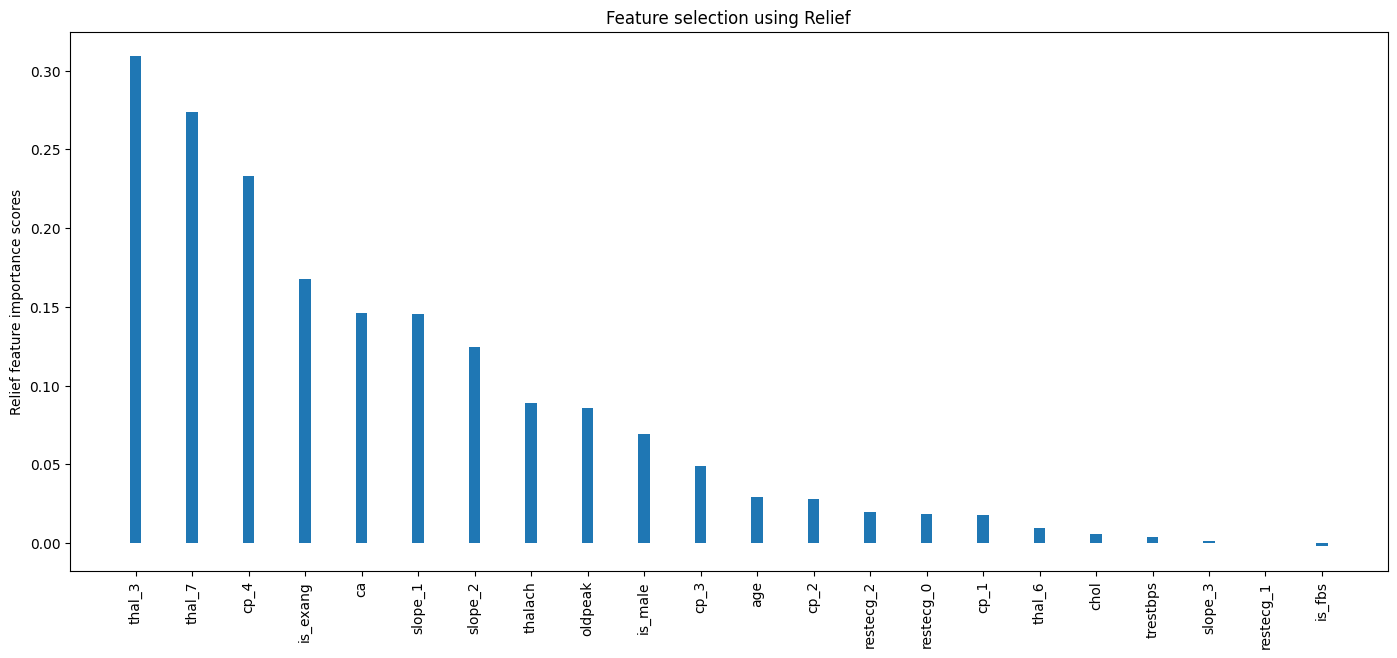

In [30]:
relief_scores = reliefFS.feature_importances_
cols = reliefFS.top_features_
feat = cols[:]
# Create the plot
plt.figure(figsize=(17,7))
plt.figure(1)
plt.clf()
plt.bar(range(0, len(relief_scores[feat])), relief_scores[feat], width=0.2)
plt.title("Feature selection using Relief")
plt.xticks(range(0, len(relief_scores[feat])),X_train_df.columns[feat], rotation=90)
plt.ylabel("Relief feature importance scores")
plt.show()

In [31]:
# Add features in a list for use later with the ensemble model
features_selected_lists.append(list(X_train_df.columns[feat]))

In [32]:
# Create a dataframe that contains the scores of the two methods and feature names
feature_names = X_train_df.columns
df=pd.DataFrame({'Kbest':p_val,'ReliefF':relief_scores,'Feature':feature_names})
df.set_index('Feature', inplace = True)
df.sort_values('Kbest', inplace = True, ascending = False)
df

,Kbest,ReliefF
Feature,,
is_fbs,4.773712e-01,-0.001983
slope_3,3.905489e-01,0.001240
restecg_1,3.583861e-01,0.000041
chol,2.315500e-01,0.005931
thal_6,2.277887e-01,0.009545
cp_1,1.944099e-01,0.017975
trestbps,3.435545e-02,0.003679
restecg_0,1.499515e-02,0.018347
restecg_2,1.067988e-02,0.019876


Plot the scores from the two approaches:

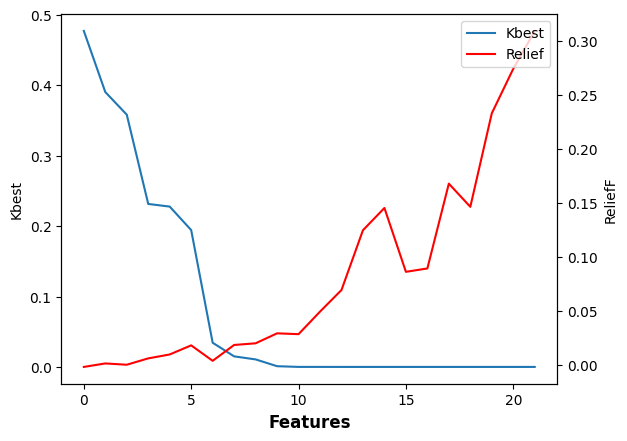

In [33]:
fig, ax = plt.subplots()
rr = range(0,len(feature_names))
# Create a twin Axes sharing the xaxis
ax2 = ax.twinx()
ax.plot(range(0,df.shape[0]), df["Kbest"], label='Kbest')
ax2.plot(range(0,df.shape[0]), df["ReliefF"], color='red', label='Relief')

ax.set_xlabel('Features', fontsize=12, fontweight='bold')
ax.set_ylabel('Kbest')
ax2.set_ylabel('ReliefF')
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax.transAxes)

#### Wrapper Method (Multivariate)

In [41]:
# define model used to evaluate feature subsets
model = LogisticRegression(max_iter=1000)

# initialize sequential feature selector
sfs = SequentialFeatureSelector(
    model,
    n_features_to_select=k,
    direction="forward",
    scoring="accuracy",
    cv=5,
    n_jobs=1
)

# fit on training data
sfs.fit(X_train_scaled, y_train)

# get selected feature names
selected_sfs = X_train.columns[sfs.get_support()]

# print selected features
print("\nSelected features (Forward Selection):")
print(selected_sfs)


Selected features (Forward Selection):
Index(['ca', 'thal_3'], dtype='str')


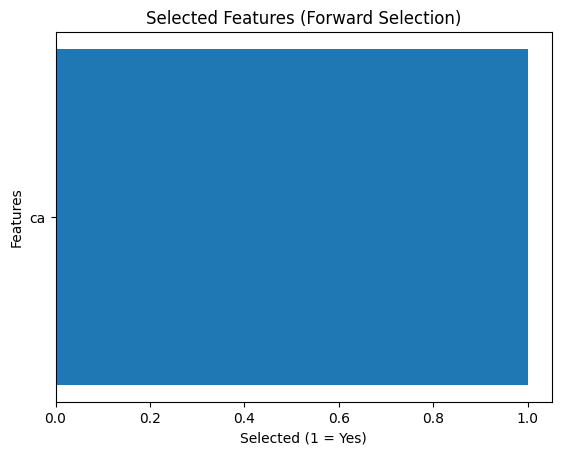

In [42]:
# Create DataFrame from wrapper results
wrapper_df = pd.DataFrame({
    "Feature": X.columns,
    "Selected": X.columns.isin(selected_sfs).astype(int)
})

# Keep only selected features
selected_wrapper_df = wrapper_df[wrapper_df["Selected"] == 1]

# Plot
plt.figure()

plt.barh(selected_wrapper_df["Feature"], selected_wrapper_df["Selected"])

plt.title("Selected Features (Forward Selection)")
plt.xlabel("Selected (1 = Yes)")
plt.ylabel("Features")

plt.show()

## Comparison between ANOVA and Wrapper Method

In [ ]:

comparison_df = pd.DataFrame({
    "Feature": X.columns,
    "ANOVA": X.columns.isin(selected_kbest).astype(int),
    "Wrapper": X.columns.isin(selected_sfs).astype(int)
})

comparison_df.set_index("Feature").plot(kind="bar", figsize=(10,5))

plt.title("Feature Selection Comparison")
plt.ylabel("Selected (1 = Yes)")
plt.xticks(rotation=90)
plt.show()

- Some features are consistently selected by both methods, indicating strong relevance, while others differ due to the wrapper method’s ability to capture interactions between variables.
- Many features were consistently selected by both methods, including `thalach`, `ca`, `cp_4.0`, and `thal_7.0`, indicating that these variables have strong predictive power and a stable relationship with the target variable. The agreement between methods increases confidence in their relevance.

- However, some features were selected by only one method. For example, ANOVA selected features such as exang_1.0 and slope_2.0, while the wrapper method selected features like cp_2.0 and fbs_1.0. This difference arises because ANOVA evaluates each feature independently, while forward selection considers interactions between features within a predictive model.

## Conclusion

The **ANOVA F-test** was used as a feature selection method to identify the most relevant variables prior to clustering. It evaluates each feature independently based on its statistical relationship with the target variable. The top-ranked features were then retained and used as input for the clustering algorithm. This approach ensures that clustering is performed on the most informative and discriminative variables, improving both interpretability and performance.

**Note**
* PCA was used to explore the structure of the dataset and revealed that the data is high-dimensional and complex. 
* Feature selection methods were then applied to identify a reduced set of meaningful and interpretable variables.
* The final selection of 8 features balances dimensionality reduction with interpretability and statistical relevance, providing a strong foundation for subsequent clustering analysis.

## Summary of steps performed
**1- Data preprocessing**\
* Loading a dataset using **pandas**
* Checking for **missing values** and dataset **shape**
* Understanding dataset structure with `.info()` and `.describe()`

 **2- Encoding of categorical variables**\
 **3- Standardization, check scaling**\
**4- Target Variable Preparation**\
### Step A:  Principal Component Analysis (PCA)**
**6- Screen Plot**\
**7-Cumulative Variance Plot**\
**8-PCA Projection with target**\
### Step B Feature Selection
**9- Split dataset in Training and Test**\
**10- Filter Method- AVOVA F-Test**\
**11- Feature score (F-score) and Plot**\
**12- Wrapper Method - Forward feature selection and Plot**\
**13- Comparasion plot of ANOVA and Wrapper Method**\

### Export selected feature
### Conclusion




